In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# data = pd.read_csv("steam.csv")
# df = pd.DataFrame(data)
# print(df.shape)
# print(df.head().T)


In [3]:
# game_percentage = (
#     df["app_name"]
#     .value_counts(normalize=True)
#     * 100
# )

# print(game_percentage.head(20))

In [4]:


# df["review_score"].value_counts()

In [5]:
# This is steam game review dataset. on keggal it contain too much  data 
# so, we take 80k data from it. 40k positive and 40k negative data. 

# import pandas as pd


# df = pd.read_csv("steam.csv")


# df = df[["app_name", "review_text", "review_score"]]

# remove missing values
# df = df.dropna(subset=["review_text", "review_score"])

# remove duplicates
# df = df.drop_duplicates(subset=["review_text"])

# separate positive and negative reviews
# positive = df[df["review_score"] == 1]
# negative = df[df["review_score"] == -1]

# print("Original Dataset")
# print(df["review_score"].value_counts())

# rendomly sample 40k positive and 40k negative reviews
# positive_sample = positive.sample(
#     n=40000,
#     random_state=42
# )

# negative_sample = negative.sample(
#     n=40000,
#     random_state=42
# )

# # Combine
# balanced_df = pd.concat(
#     [positive_sample, negative_sample],
#     ignore_index=True
# )

# # Shuffle the rows
# balanced_df = balanced_df.sample(
#     frac=1,
#     random_state=42
# ).reset_index(drop=True)

# print("\nBalanced Dataset")
# print(balanced_df["review_score"].value_counts())

# #Save CSV
# balanced_df.to_csv(
#     "balanced_game_reviews_80k.csv",
#     index=False
# )

# print("\nDataset Saved Successfully!")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# word cloud
from wordcloud import WordCloud

# feature extraction

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)


# 6. train test 
from sklearn.model_selection import train_test_split

# machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 8. model evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import pickle

import warnings
warnings.filterwarnings("ignore")

In [7]:
import nltk

# download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")   # Required for newer NLTK versions
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
df = pd.read_csv("balanced_game_reviews_80k.csv")
df.head()

,app_name,review_text,review_score
0,PAYDAY 2,So. After reading my last review for this game...,-1
1,Magic Duels,Ridiculously expensive to do anything with and...,-1
2,Nidhogg,Fifteen bucks for this? Are you out of your mi...,-1
3,X-Blades,"Kill enemies, wait until 10 waves of them resp...",-1
4,FINAL FANTASY TYPE-0 HD,This game suffers from the same problems as in...,-1


In [9]:
print("Dataset Shape :", df.shape)
print(df.columns)
df.info()

Dataset Shape : (80000, 3)
Index(['app_name', 'review_text', 'review_score'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   app_name      77069 non-null  object
 1   review_text   80000 non-null  object
 2   review_score  80000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.8+ MB


In [10]:
print("missing values:",df.isnull().sum())
print("\nDuplicate Rows :", df.duplicated().sum())
df["app_name"] = df["app_name"].fillna("Unknown Game")

missing values: app_name        2931
review_text        0
review_score       0
dtype: int64

Duplicate Rows : 0


In [11]:
#Never modify the original dataset.
#If something goes wrong, your original dataset remains unchanged.
# Create copy for preprocessing
pre_df = df.copy()

# Keep only required columns
pre_df = pre_df[["review_text", "review_score"]]

pre_df.head()

,review_text,review_score
0,So. After reading my last review for this game...,-1
1,Ridiculously expensive to do anything with and...,-1
2,Fifteen bucks for this? Are you out of your mi...,-1
3,"Kill enemies, wait until 10 waves of them resp...",-1
4,This game suffers from the same problems as in...,-1


In [12]:
# Convert reviews to lowercase
def lowercase_text(text):
    return text.lower()

pre_df["review_text"] = pre_df["review_text"].apply(lowercase_text)

In [13]:
#Remove HTML Tags
#Sometimes reviews contain HTML.
import re

def remove_html(text):
    clean = re.compile("<.*?>")
    return re.sub(clean, "", text)

pre_df["review_text"] = pre_df["review_text"].apply(remove_html)

In [14]:
# Remove URLs
# Reviews may contain links.

def remove_url(text):
    return re.sub(r"http\S+|www\S+|https\S+", "", text)

pre_df["review_text"] = pre_df["review_text"].apply(remove_url)

In [15]:
#Remove Numbers
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

pre_df["review_text"] = pre_df["review_text"].apply(remove_numbers)
pre_df.head()

,review_text,review_score
0,so. after reading my last review for this game...,-1
1,ridiculously expensive to do anything with and...,-1
2,fifteen bucks for this? are you out of your mi...,-1
3,"kill enemies, wait until waves of them respaw...",-1
4,this game suffers from the same problems as in...,-1


In [16]:
# Remove Punctuation
import string

def remove_punctuation(text):
    return text.translate(
        str.maketrans("", "", string.punctuation)
    )

pre_df["review_text"] = pre_df["review_text"].apply(remove_punctuation)

In [17]:
# # Install emoji library (Run only once)
# !pip install -q emoji

# Import library
import emoji

# Function to remove emojis
def remove_emojis(text):
    if isinstance(text, str):
        return emoji.replace_emoji(text, replace="")
    return text

# Remove emojis from review_text column
pre_df["review_text"] = pre_df["review_text"].apply(remove_emojis)

# Display first 5 rows
pre_df.head()

,review_text,review_score
0,so after reading my last review for this game ...,-1
1,ridiculously expensive to do anything with and...,-1
2,fifteen bucks for this are you out of your min...,-1
3,kill enemies wait until waves of them respawn...,-1
4,this game suffers from the same problems as in...,-1


In [18]:
import nltk
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt')

# Create a new column with tokenized words
def tokenize_text(text):
    return word_tokenize(text)

pre_df["tokens"] = pre_df["review_text"].apply(tokenize_text)

pre_df[["review_text", "tokens"]].head()

# Display first 5 rowsx
pre_df[["review_text", "tokens"]].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,review_text,tokens
0,so after reading my last review for this game ...,"[so, after, reading, my, last, review, for, th..."
1,ridiculously expensive to do anything with and...,"[ridiculously, expensive, to, do, anything, wi..."
2,fifteen bucks for this are you out of your min...,"[fifteen, bucks, for, this, are, you, out, of,..."
3,kill enemies wait until waves of them respawn...,"[kill, enemies, wait, until, waves, of, them, ..."
4,this game suffers from the same problems as in...,"[this, game, suffers, from, the, same, problem..."


In [19]:
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Keep important negation words
stop_words = stop_words - {"not", "no", "nor", "never"}


# Function to remove stopwords
def remove_stopwords(words):
    return [
        word
        for word in words
        if word not in stop_words
    ]


# Apply stopword removal
pre_df["tokens"] = pre_df["tokens"].apply(remove_stopwords)


# Display results
pre_df[["review_text", "tokens"]].head()

,review_text,tokens
0,so after reading my last review for this game ...,"[reading, last, review, game, thinking, game, ..."
1,ridiculously expensive to do anything with and...,"[ridiculously, expensive, anything, matched, d..."
2,fifteen bucks for this are you out of your min...,"[fifteen, bucks, mind, remember, final, boss, ..."
3,kill enemies wait until waves of them respawn...,"[kill, enemies, wait, waves, respawn, beat, le..."
4,this game suffers from the same problems as in...,"[game, suffers, problems, indie, developers, n..."


In [20]:
# Lemmatization converts different forms of a word into its base (dictionary) form.
from nltk.stem import WordNetLemmatizer

# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Function for lemmatization
def lemmatize_words(words):
    return [
        lemmatizer.lemmatize(word, pos="v")
        for word in words
    ]

# Function to remove words with length <= 2
def remove_short_words(words):
    return [
        word
        for word in words
        if len(word) > 2
    ]

# Apply lemmatization
pre_df["tokens"] = pre_df["tokens"].apply(lemmatize_words)
# Remove short words
pre_df["tokens"] = pre_df["tokens"].apply(remove_short_words)
# Display first 5 rows
pre_df[["review_text", "tokens"]].head()



,review_text,tokens
0,so after reading my last review for this game ...,"[read, last, review, game, think, game, nowi, ..."
1,ridiculously expensive to do anything with and...,"[ridiculously, expensive, anything, match, due..."
2,fifteen bucks for this are you out of your min...,"[fifteen, buck, mind, remember, final, boss, a..."
3,kill enemies wait until waves of them respawn...,"[kill, enemies, wait, wave, respawn, beat, lev..."
4,this game suffers from the same problems as in...,"[game, suffer, problems, indie, developers, fo..."


In [21]:
def remove_repeated(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

pre_df["review_text"] = pre_df["review_text"].apply(remove_repeated)

In [22]:
# Function to convert token list back into a sentence
def join_tokens(words):
    return " ".join(words)


# Convert token list back into a sentence
pre_df["clean_review"] = pre_df["tokens"].apply(join_tokens)


# Check the first 5 rows
pre_df[["tokens", "clean_review"]].head()


,tokens,clean_review
0,"[read, last, review, game, think, game, nowi, ...",read last review game think game nowi see good...
1,"[ridiculously, expensive, anything, match, due...",ridiculously expensive anything match duel utt...
2,"[fifteen, buck, mind, remember, final, boss, a...",fifteen buck mind remember final boss arcade f...
3,"[kill, enemies, wait, wave, respawn, beat, lev...",kill enemies wait wave respawn beat level beat...
4,"[game, suffer, problems, indie, developers, fo...",game suffer problems indie developers foresigh...


In [23]:
# Features (Input)
X = pre_df["clean_review"]

# Target (Output)
y = pre_df["review_score"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (80000,)
Shape of y: (80000,)


In [24]:
print(pre_df.columns)

Index(['review_text', 'review_score', 'tokens', 'clean_review'], dtype='object')


In [25]:
print(pre_df["clean_review"].head())



0    read last review game think game nowi see good...
1    ridiculously expensive anything match duel utt...
2    fifteen buck mind remember final boss arcade f...
3    kill enemies wait wave respawn beat level beat...
4    game suffer problems indie developers foresigh...
Name: clean_review, dtype: object


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF object
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Convert text into numerical features
X = tfidf.fit_transform(X)

print("Shape after TF-IDF:", X.shape)

import pickle

# Save the trained TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("tfidf_vectorizer.pkl created successfully!")

import pickle

with open("tfidf_vectorizer.pkl", "rb") as file:
    tfidf_test = pickle.load(file)

print("TF-IDF loaded successfully!")
print("Number of features:", len(tfidf_test.get_feature_names_out()))

Shape after TF-IDF: (80000, 15000)
tfidf_vectorizer.pkl created successfully!
TF-IDF loaded successfully!
Number of features: 15000


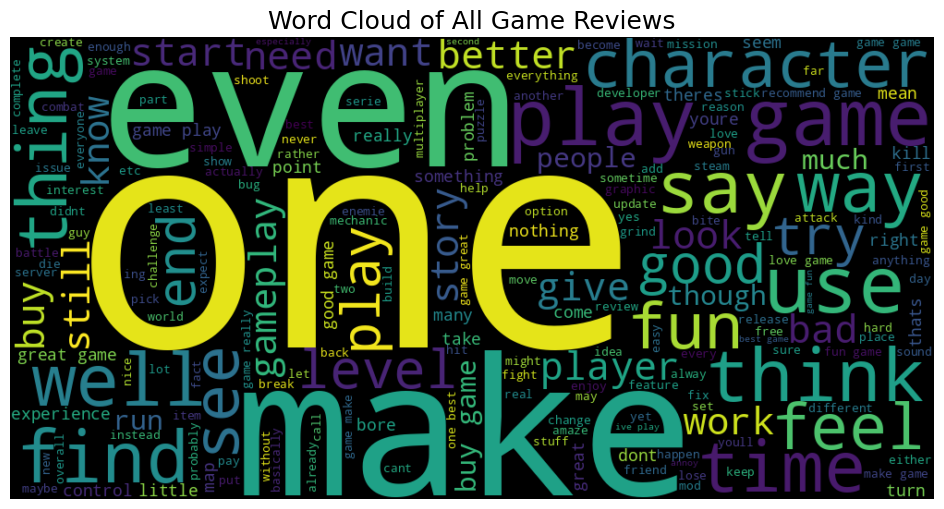

In [27]:
text = " ".join(pre_df["clean_review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black"
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of All Game Reviews", fontsize=18)
plt.show()

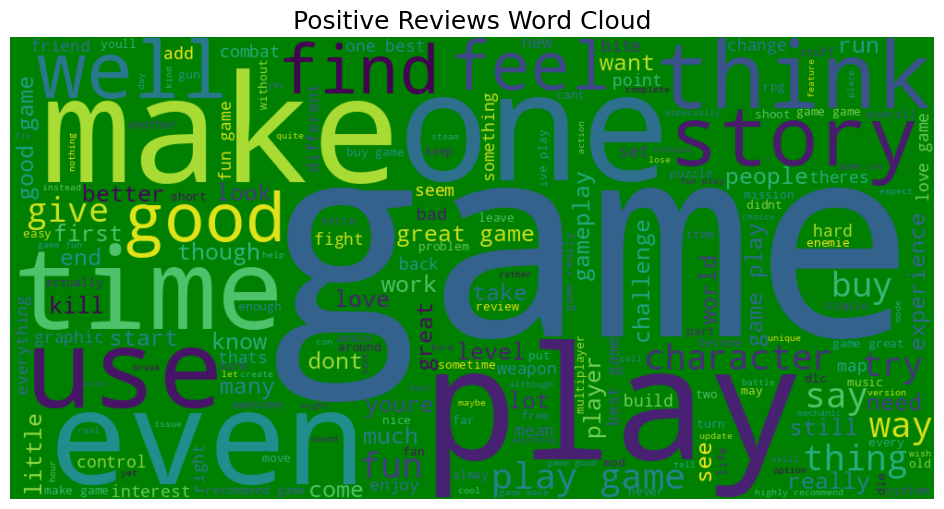

In [28]:
positive_text = " ".join(
    pre_df[pre_df["review_score"] == 1]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="green"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud", fontsize=18)
plt.show()

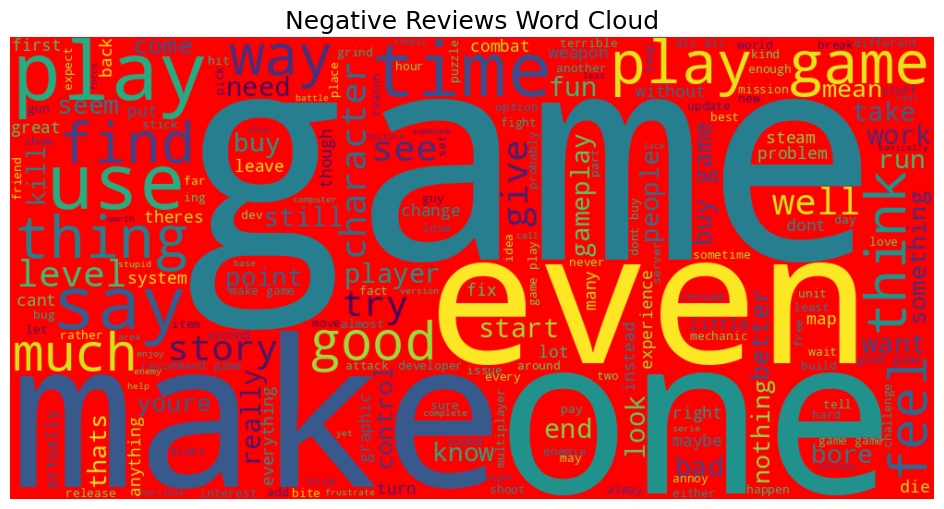

In [29]:
negative_text = " ".join(
    pre_df[pre_df["review_score"] == -1]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="red"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud", fontsize=18)
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (64000, 15000)
Testing Shape: (16000, 15000)


In [31]:
from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(
    C=2,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

# Train model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

import pickle

# Save the trained Logistic Regression model
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("sentiment_model.pkl created successfully!")

sentiment_model.pkl created successfully!


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix")
print(cm)

Accuracy : 0.8564375
Precision: 0.8520805037658971
Recall   : 0.862625
F1 Score : 0.8573203304553078
              precision    recall  f1-score   support

          -1       0.86      0.85      0.86      8000
           1       0.85      0.86      0.86      8000

    accuracy                           0.86     16000
   macro avg       0.86      0.86      0.86     16000
weighted avg       0.86      0.86      0.86     16000

Confusion Matrix
[[6802 1198]
 [1099 6901]]


In [33]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# User Input
review = input("Enter Game Review: ")

# Initialize
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
stop_words = stop_words - {"not", "no", "nor", "never"}

# Preprocessing
review = review.lower()
review = re.sub(r"http\S+|www\S+", "", review)
review = re.sub(r"<.*?>", "", review)
review = re.sub(r"[^\w\s]", " ", review)
review = re.sub(r"\d+", "", review)
review = re.sub(r"\s+", " ", review).strip()

tokens = review.split()
tokens = [word for word in tokens if word not in stop_words]
tokens = [lemmatizer.lemmatize(word) for word in tokens]

clean_review = " ".join(tokens)

# TF-IDF
review_vector = tfidf.transform([clean_review])

# Prediction
prediction = lr.predict(review_vector)[0]
probability = lr.predict_proba(review_vector)[0]

if prediction == 1:
    print("\nPrediction : Positive ")
else:
    print("\nPrediction : Negative ")

print(f"Positive Confidence : {probability[1]*100:.2f}%")
print(f"Negative Confidence : {probability[0]*100:.2f}%")


Prediction : Positive 
Positive Confidence : 60.08%
Negative Confidence : 39.92%


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create Model
nb = MultinomialNB()

# Train Model
nb.fit(X_train, y_train)

# Prediction
y_pred_nb = nb.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
cm = confusion_matrix(y_test, y_pred_nb)

# Print Results
print("=" * 50)
print("Multinomial Naive Bayes Results")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

In [35]:
# import pickle

# preprocessing_functions = {
#     "lowercase_text": lowercase_text,
#     "remove_html": remove_html,
#     "remove_emojis": remove_emojis,
#     "tokenize_text": tokenize_text,
#     "remove_stopwords": remove_stopwords,
#     "lemmatize_words": lemmatize_words,
#     "remove_short_words": remove_short_words,
#     "join_tokens": join_tokens
# }

# with open("preprocessing.pkl", "wb") as file:
#     pickle.dump(preprocessing_functions, file)

# print("preprocessing.pkl created successfully!")

# for function_name in preprocessing_functions:
#     print("-", function_name)

In [36]:
# import pickle
# from Utils.preprocessing import preprocessing

# with open("preprocessing.pkl", "wb") as file:
#     pickle.dump(preprocessing, file)

# print("preprocessing.pkl created successfully")

In [37]:
# we are using the preporcessing dairectly in prediction page on streamlit because
# the imbalance of functions sequence and the need to maintain the order of preprocessing steps.
# This ensures that the input data is processed consistently before making predictions, avoiding any 
# discrepancies that could arise from loading functions separately.

In [38]:
from data_profiling import ProfileReport
# Create the automated EDA report
profile = ProfileReport(
    df,
    title="game review data analysis",
    explorative=True
)
# Show the report
profile


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:09<00:00,  3.23s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
profile.to_file("game_review_analysis_EDA_Report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]